In [1]:
!pip install -q torch torchvision matplotlib


In [9]:
import torch
import torchvision
import matplotlib.pyplot as plt

print("PyTorch :" ,torch.version.__version__)

PyTorch : 2.11.0+cpu


In [12]:
use_gpu = torch.cuda.is_available()
print("GPU is available :" ,use_gpu)

model = torch.hub.load("facebookresearch/pytorch_GAN_zoo:hub","DCGAN",pretrained = True ,useGPU=use_gpu)
print("DCGAN load Sucessfully")

GPU is available : False
Average network found !


Using cache found in /root/.cache/torch/hub/facebookresearch_pytorch_GAN_zoo_hub


DCGAN load Sucessfully


In [15]:
num_images = 16
noise, _ = model.buildNoiseData(num_images)
print("Noise Shape :",noise.shape)

Noise Shape : torch.Size([16, 120])


In [16]:
with torch.no_grad():
  generated_images=model.test(noise)
print("Generated images shape:",generated_images.shape)

Generated images shape: torch.Size([16, 3, 64, 64])


In [17]:
grid=torchvision.utils.make_grid(
    generated_images,
    nrow=4,
)

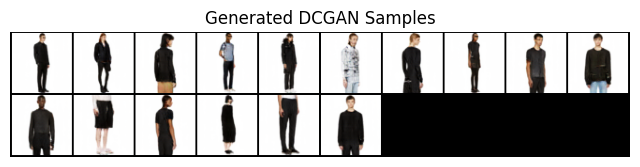

In [19]:
grid = torchvision.utils.make_grid(
    generated_images,
    nrow=10,
    normalize=True,
    scale_each=True
)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis("off")
plt.title("Generated DCGAN Samples")
plt.show()
